# Fine-Tuning ProPicker on UMU Synthetic Thyroglobulin Dataset

This notebook demonstrates how to fine-tune ProPicker for picking **thyroglobulin** particles in the UMU synthetic dataset.

## Overview

The UMU synthetic dataset contains 25 tomograms with approximately **3,327 thyroglobulin instances** (label=7 in the CSV). Each tomogram contains ~120-150 thyroglobulin particles with full 3D coordinates and rotation quaternions.

For fine-tuning, we:
1. Update CSV paths to point to the local data directory
2. Extract thyroglobulin coordinates and rotations from the CSV
3. Generate 37×37×37 subtomogram patches for prompt extraction
4. Fine-tune ProPicker with the extracted data

## Prerequisites

Before running this notebook, ensure you have:
1. Configured paths in `config.py` at project root
2. Downloaded the UMU synthetic dataset to `data/umu_synth/`
3. Downloaded the TomoTwin model checkpoint

In [1]:
import sys
from pathlib import Path

# Add project root and experiments to path
PROJECT_ROOT = Path("../..").resolve()
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "experiments"))

# Import paths (file system locations)
from paths import (
    UMU_SYNTH_DIR,
    UMU_SYNTH_TOMOS_DIR,
    UMU_SYNTH_CSV,
    TOMOTWIN_MODEL_FILE,
    PROPICKER_TOOLS_DIR,
    EXP2_RESULTS_DIR,
    EXP2_FINETUNING_DIR,
    EXP2_DATA_DIR,
    EXP2_COORDS_DIR,
)

# Import config (experiment parameters and utilities)
from config import (
    setup_propicker_paths,
    THYROGLOBULIN_NAME,
    THYROGLOBULIN_LABEL,
    PROMPT_SIZE,
    PROMPT_HALF,
    THYROGLOBULIN_DIAMETER,
    LABEL_DIAMETER,
)

# Setup ProPicker imports
PROPICKER_DIR = setup_propicker_paths()

# Alias for compatibility with the rest of the notebook
PARTICLE_TYPE = THYROGLOBULIN_NAME
EXP_RESULTS_DIR = EXP2_RESULTS_DIR
FINETUNING_DIR = EXP2_FINETUNING_DIR
DATA_DIR = EXP2_DATA_DIR
COORDS_DIR = EXP2_COORDS_DIR

# Create directories if they don't exist
EXP_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FINETUNING_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)
COORDS_DIR.mkdir(parents=True, exist_ok=True)

import subprocess
import pandas as pd
import numpy as np
import torch
from matplotlib import pyplot as plt

from inference.tomotwin import get_tomotwin_prompt_embeds_dict
from utils.mrctools import load_mrc_data

import warnings
warnings.filterwarnings("ignore")

print(f"ProPicker tools: {PROPICKER_DIR}")
print(f"UMU Synth data: {UMU_SYNTH_DIR}")
print(f"Tomograms dir: {UMU_SYNTH_TOMOS_DIR}")
print(f"TomoTwin model: {TOMOTWIN_MODEL_FILE}")
print(f"Results dir: {EXP_RESULTS_DIR}")
print(f"\nThyroglobulin parameters:")
print(f"  Particle type: {PARTICLE_TYPE}")
print(f"  Label in CSV: {THYROGLOBULIN_LABEL}")
print(f"  Prompt size: {PROMPT_SIZE}×{PROMPT_SIZE}×{PROMPT_SIZE}")
print(f"  Diameter: {THYROGLOBULIN_DIAMETER}")

ProPicker tools: /home/carlos-hg/Dev/cryoet-particle-picking/tools/ProPicker
UMU Synth data: /home/carlos-hg/Dev/cryoet-particle-picking/data/umu_synth/umu_synth
Tomograms dir: /home/carlos-hg/Dev/cryoet-particle-picking/data/umu_synth/umu_synth/tomos
TomoTwin model: /home/carlos-hg/Dev/cryoet-particle-picking/models/TomoTwin/tomotwin.pth
Results dir: /home/carlos-hg/Dev/cryoet-particle-picking/results/exp2_umusynth_thy

Thyroglobulin parameters:
  Particle type: thyroglobulin
  Label in CSV: 7
  Prompt size: 37×37×37
  Diameter: 30


## Step 0: Update CSV Paths

The CSV file contains paths from the original system. We need to update the `Tomo3D` column to point to our local data directory using the `update_csv_paths.py` script.

In [2]:
# Path to the update script
UPDATE_SCRIPT = PROJECT_ROOT / "experiments" / "exp2_umusynth_thy" / "scripts" / "update_csv_paths.py"

# Output CSV with updated paths
UPDATED_CSV = DATA_DIR / "tomos_motif_list_updated.csv"

# Run the script to update paths (dry-run first to preview)
print("Preview of path changes (dry-run):")
cmd_preview = [
    "python", str(UPDATE_SCRIPT),
    str(UMU_SYNTH_CSV),
    "--columns", "Tomo3D",
    "--new-dir", str(UMU_SYNTH_TOMOS_DIR),
    "--dry-run"
]
result = subprocess.run(cmd_preview, capture_output=True, text=True)
print(result.stdout)
if result.stderr:
    print("Errors:", result.stderr)

Preview of path changes (dry-run):
[DRY RUN] Processing file: /home/carlos-hg/Dev/cryoet-particle-picking/data/umu_synth/umu_synth/tomos_motif_list.csv
Columns to update: Tomo3D
New directory: /home/carlos-hg/Dev/cryoet-particle-picking/data/umu_synth/umu_synth/tomos
Delimiter: TAB
--------------------------------------------------------------------------------
Header found: 15 columns
  - 'Tomo3D' (index 3)
--------------------------------------------------------------------------------
Column 'Tomo3D':
  Before:  /home/aguilar/Projects/polnet/data/data_generated/25_more_ribos_and_distractors/tomos/tomo_rec_0_snr1.63.mrc
  After: /home/carlos-hg/Dev/cryoet-particle-picking/data/umu_synth/umu_synth/tomos/tomo_rec_0_snr1.63.mrc
Column 'Tomo3D':
  Before:  /home/aguilar/Projects/polnet/data/data_generated/25_more_ribos_and_distractors/tomos/tomo_rec_0_snr1.63.mrc
  After: /home/carlos-hg/Dev/cryoet-particle-picking/data/umu_synth/umu_synth/tomos/tomo_rec_0_snr1.63.mrc
Column 'Tomo3D':
  

In [3]:
# Apply the path update (this creates the updated CSV)
print("Applying path update...")
cmd_apply = [
    "python", str(UPDATE_SCRIPT),
    str(UMU_SYNTH_CSV),
    "--columns", "Tomo3D",
    "--new-dir", str(UMU_SYNTH_TOMOS_DIR),
    "--output", str(UPDATED_CSV)
]
result = subprocess.run(cmd_apply, capture_output=True, text=True)
print(result.stdout)
if result.stderr:
    print("Errors:", result.stderr)

print(f"\n✅ Updated CSV saved to: {UPDATED_CSV}")

Applying path update...
Processing file: /home/carlos-hg/Dev/cryoet-particle-picking/data/umu_synth/umu_synth/tomos_motif_list.csv
Columns to update: Tomo3D
New directory: /home/carlos-hg/Dev/cryoet-particle-picking/data/umu_synth/umu_synth/tomos
Delimiter: TAB
--------------------------------------------------------------------------------
Header found: 15 columns
  - 'Tomo3D' (index 3)
--------------------------------------------------------------------------------
Processed 100,000 rows...
Processed 200,000 rows...
Processed 300,000 rows...
Processed 400,000 rows...
Processed 500,000 rows...
Processed 600,000 rows...
Processed 700,000 rows...
Processed 800,000 rows...
Processed 900,000 rows...
Processed 1,000,000 rows...
Processed 1,100,000 rows...
Processed 1,200,000 rows...
Processed 1,300,000 rows...
Processed 1,400,000 rows...
Processed 1,500,000 rows...
Processed 1,600,000 rows...
Processed 1,700,000 rows...
Processed 1,800,000 rows...
Processed 1,900,000 rows...
Processed 2,00

## Step 1: Load and Filter Thyroglobulin Data

Load the updated CSV and filter for thyroglobulin instances (Label=7). Group by tomogram (Tomo3D column) and extract coordinates and rotations.

In [4]:
# Load the updated CSV
print(f"Loading CSV from: {UPDATED_CSV}")
df = pd.read_csv(UPDATED_CSV, sep='\t')

print(f"Total rows in CSV: {len(df):,}")
print(f"Columns: {list(df.columns)}")

# Filter for thyroglobulin (Label=7)
df_thy = df[df['Label'] == THYROGLOBULIN_LABEL].copy()
print(f"\nThyroglobulin instances (Label={THYROGLOBULIN_LABEL}): {len(df_thy):,}")

# Group by tomogram (Tomo3D column)
tomo_groups = df_thy.groupby('Tomo3D')
print(f"Number of tomograms: {len(tomo_groups)}")

# Show distribution per tomogram
print("\nThyroglobulin instances per tomogram:")
for tomo_path, group in tomo_groups:
    tomo_name = Path(tomo_path).stem
    print(f"  {tomo_name}: {len(group)} instances")

Loading CSV from: /home/carlos-hg/Dev/cryoet-particle-picking/results/exp2_umusynth_thy/data/tomos_motif_list_updated.csv
Total rows in CSV: 6,094,626
Columns: ['Density', 'Micrographs', 'PolyData', 'Tomo3D', 'Type', 'Label', 'Code', 'Polymer', 'X', 'Y', 'Z', 'Q1', 'Q2', 'Q3', 'Q4']

Thyroglobulin instances (Label=7): 3,327
Number of tomograms: 25

Thyroglobulin instances per tomogram:
  tomo_rec_0_snr1.63: 148 instances
  tomo_rec_10_snr0.97: 153 instances
  tomo_rec_11_snr1.41: 148 instances
  tomo_rec_12_snr1.39: 143 instances
  tomo_rec_13_snr1.1: 116 instances
  tomo_rec_14_snr0.43: 150 instances
  tomo_rec_15_snr1.03: 118 instances
  tomo_rec_16_snr0.93: 148 instances
  tomo_rec_17_snr0.92: 136 instances
  tomo_rec_18_snr0.78: 142 instances
  tomo_rec_19_snr1.62: 144 instances
  tomo_rec_1_snr1.46: 118 instances
  tomo_rec_20_snr0.73: 150 instances
  tomo_rec_21_snr0.34: 122 instances
  tomo_rec_22_snr0.97: 119 instances
  tomo_rec_23_snr0.29: 122 instances
  tomo_rec_24_snr1.39:

In [5]:
# Extract coordinates and rotations per tomogram
# Columns: X, Y, Z for coordinates; Q1, Q2, Q3, Q4 for rotation quaternions
# IMPORTANT: CSV coordinates are in ANGSTROMS, need to convert to voxels

import mrcfile

coords_by_tomo = {}
for tomo_path, group in tomo_groups:
    tomo_name = Path(tomo_path).stem
    
    # Read voxel size from MRC header to convert Angstroms -> voxels
    with mrcfile.open(tomo_path, mode='r') as mrc:
        voxel_size = float(mrc.voxel_size.x)  # Assuming isotropic voxels (~10 Å)
    
    # Get coordinates in Angstroms from CSV
    coords_angstrom = group[['X', 'Y', 'Z']].values.astype(np.float32)
    
    # Convert to voxel coordinates
    coords_voxels = coords_angstrom / voxel_size
    
    coords_data = {
        'coords': coords_voxels,  # Now in voxels!
        'coords_angstrom': coords_angstrom,  # Keep original for reference
        'quaternions': group[['Q1', 'Q2', 'Q3', 'Q4']].values.astype(np.float32),
        'tomo_path': tomo_path,
        'voxel_size': voxel_size
    }
    coords_by_tomo[tomo_name] = coords_data

# Save coordinates to files for later use
print("Saving coordinates per tomogram...")
for tomo_name, data in coords_by_tomo.items():
    coord_file = COORDS_DIR / f"{tomo_name}_thyroglobulin_coords.csv"
    coord_df = pd.DataFrame({
        'X': data['coords'][:, 0],
        'Y': data['coords'][:, 1],
        'Z': data['coords'][:, 2],
        'Q1': data['quaternions'][:, 0],
        'Q2': data['quaternions'][:, 1],
        'Q3': data['quaternions'][:, 2],
        'Q4': data['quaternions'][:, 3],
    })
    coord_df.to_csv(coord_file, index=False)
    
print(f"✅ Saved coordinates for {len(coords_by_tomo)} tomograms to {COORDS_DIR}")

# Show sample data with conversion info
sample_tomo = list(coords_by_tomo.keys())[0]
sample_data = coords_by_tomo[sample_tomo]
print(f"\nSample data from {sample_tomo}:")
print(f"  Voxel size: {sample_data['voxel_size']:.4f} Å")
print(f"  Coordinates shape: {sample_data['coords'].shape}")
print(f"  First 3 coords (Angstroms): {sample_data['coords_angstrom'][:3]}")
print(f"  First 3 coords (voxels):    {sample_data['coords'][:3]}")
print(f"  Coord range X (voxels): {sample_data['coords'][:, 0].min():.1f} - {sample_data['coords'][:, 0].max():.1f}")
print(f"  Coord range Y (voxels): {sample_data['coords'][:, 1].min():.1f} - {sample_data['coords'][:, 1].max():.1f}")
print(f"  Coord range Z (voxels): {sample_data['coords'][:, 2].min():.1f} - {sample_data['coords'][:, 2].max():.1f}")

Saving coordinates per tomogram...
✅ Saved coordinates for 25 tomograms to /home/carlos-hg/Dev/cryoet-particle-picking/results/exp2_umusynth_thy/coords

Sample data from tomo_rec_0_snr1.63:
  Voxel size: 10.0124 Å
  Coordinates shape: (148, 3)
  First 3 coords (Angstroms): [[5728.3354 2944.0488  887.9456]
 [3459.549  5800.0464 1499.4298]
 [5960.4595 2534.0723 1287.8588]]
  First 3 coords (voxels):    [[572.1216  294.03897  88.6842 ]
 [345.52493 579.28375 149.75662]
 [595.3051  253.09227 128.62581]]
  Coord range X (voxels): 11.1 - 616.0
  Coord range Y (voxels): 15.4 - 617.8
  Coord range Z (voxels): 11.0 - 172.3


## Step 2: Extract Subtomograms (37×37×37 patches)

Extract 37×37×37 subtomogram patches around each thyroglobulin coordinate. This size is required by the TomoTwin prompt encoder.

In [6]:
def extract_subtomograms(tomo, coords, patch_size=37):
    """
    Extract subtomograms of given size around each coordinate.
    
    Args:
        tomo: 3D tensor (Z, Y, X)
        coords: Array of (X, Y, Z) coordinates
        patch_size: Size of subtomogram (default 37 for TomoTwin)
        
    Returns:
        List of valid subtomograms (patch_size x patch_size x patch_size)
    """
    half = patch_size // 2  # 18 for patch_size=37
    subtomos = []
    valid_coords = []
    
    for coord in coords:
        x, y, z = coord.astype(int)
        
        # Extract patch centered at (x, y, z)
        # Note: tomo is (Z, Y, X) but coords are (X, Y, Z)
        z_start, z_end = z - half, z + half + 1
        y_start, y_end = y - half, y + half + 1
        x_start, x_end = x - half, x + half + 1
        
        # Check bounds
        if (z_start < 0 or z_end > tomo.shape[0] or
            y_start < 0 or y_end > tomo.shape[1] or
            x_start < 0 or x_end > tomo.shape[2]):
            continue
            
        subtomo = tomo[z_start:z_end, y_start:y_end, x_start:x_end]
        
        # Verify correct shape
        if subtomo.shape == (patch_size, patch_size, patch_size):
            subtomos.append(subtomo)
            valid_coords.append(coord)
            
    return subtomos, np.array(valid_coords)

# Test extraction on one tomogram
test_tomo_name = list(coords_by_tomo.keys())[0]
test_tomo_data = coords_by_tomo[test_tomo_name]

print(f"Loading tomogram: {test_tomo_data['tomo_path']}")
tomo = load_mrc_data(test_tomo_data['tomo_path']).float()
print(f"Tomogram shape: {tomo.shape}")

# Extract subtomograms
subtomos, valid_coords = extract_subtomograms(
    tomo, 
    test_tomo_data['coords'], 
    patch_size=PROMPT_SIZE
)

print(f"\nExtracted {len(subtomos)} valid subtomograms of shape {PROMPT_SIZE}×{PROMPT_SIZE}×{PROMPT_SIZE}")
print(f"Original coordinates: {len(test_tomo_data['coords'])}")
print(f"Valid coordinates (not at edges): {len(valid_coords)}")

# Verify patch shape
if subtomos:
    print(f"\n✅ Subtomogram shape verification: {subtomos[0].shape}")

Loading tomogram: /home/carlos-hg/Dev/cryoet-particle-picking/data/umu_synth/umu_synth/tomos/tomo_rec_0_snr1.63.mrc
Tomogram shape: torch.Size([184, 630, 630])

Extracted 133 valid subtomograms of shape 37×37×37
Original coordinates: 148
Valid coordinates (not at edges): 133

✅ Subtomogram shape verification: torch.Size([37, 37, 37])


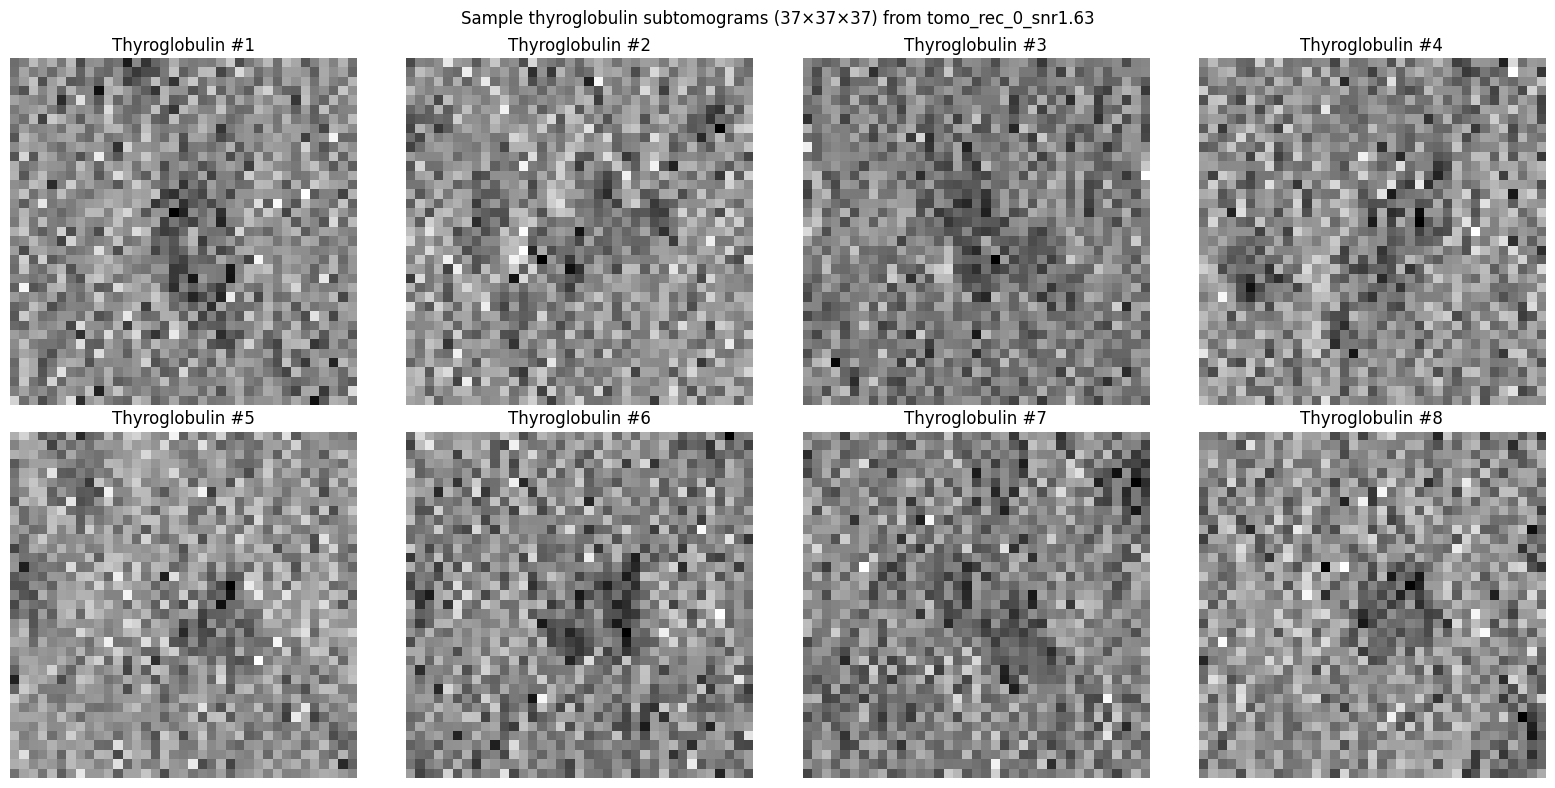

In [7]:
# Visualize sample subtomograms
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, ax in enumerate(axes.flat):
    if i < len(subtomos):
        # Show central slice of subtomogram
        subtomo = subtomos[i]
        central_slice = subtomo[PROMPT_SIZE // 2]  # Central Z slice
        ax.imshow(central_slice, cmap='gray')
        ax.set_title(f"Thyroglobulin #{i+1}")
        ax.axis('off')
    else:
        ax.axis('off')

plt.suptitle(f"Sample thyroglobulin subtomograms ({PROMPT_SIZE}×{PROMPT_SIZE}×{PROMPT_SIZE}) from {test_tomo_name}")
plt.tight_layout()
plt.show()

## Step 3: Prompt Extraction and Embedding

For fine-tuning ProPicker, we need to extract a prompt (example particle) and embed it using TomoTwin. This embedding conditions the model during fine-tuning.

Selected prompt #77 with variance 0.4640
Prompt shape: torch.Size([37, 37, 37])


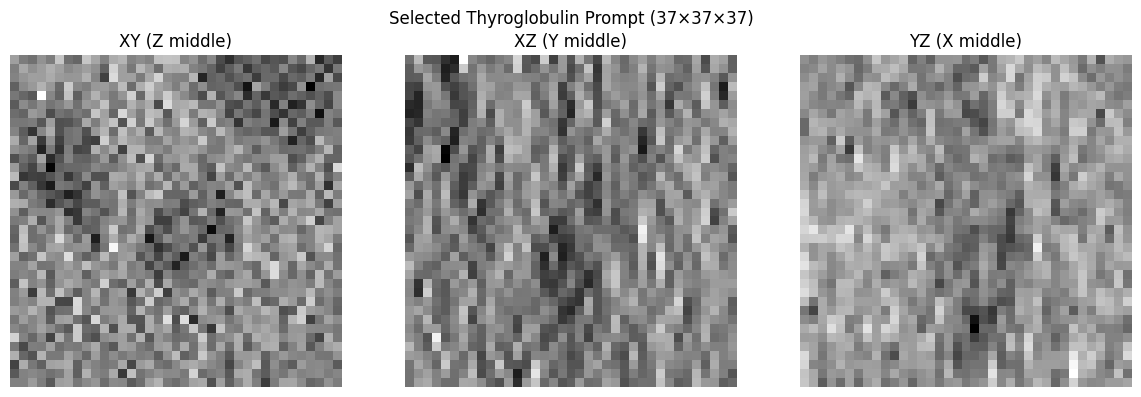

In [8]:
# Select a good prompt from the extracted subtomograms
# We use one with good signal (high variance indicates structure)
variances = [s.var().item() for s in subtomos]
best_idx = np.argmax(variances)

prompt = subtomos[best_idx]
prompt_subtomos_dict = {PARTICLE_TYPE: prompt}

print(f"Selected prompt #{best_idx} with variance {variances[best_idx]:.4f}")
print(f"Prompt shape: {prompt.shape}")

# Visualize the selected prompt
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, (ax, title) in enumerate(zip(axes, ['XY (Z middle)', 'XZ (Y middle)', 'YZ (X middle)'])):
    if i == 0:
        ax.imshow(prompt[PROMPT_SIZE//2], cmap='gray')
    elif i == 1:
        ax.imshow(prompt[:, PROMPT_SIZE//2, :], cmap='gray')
    else:
        ax.imshow(prompt[:, :, PROMPT_SIZE//2], cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.suptitle(f"Selected Thyroglobulin Prompt ({PROMPT_SIZE}×{PROMPT_SIZE}×{PROMPT_SIZE})")
plt.tight_layout()
plt.show()

In [9]:
# Embed the prompt using TomoTwin and save to disk
prompt_file = EXP_RESULTS_DIR / "fixed_prompts_umusynth_thy.json"

print(f"Embedding prompt using TomoTwin model: {TOMOTWIN_MODEL_FILE}")
prompt_embeds_dict = get_tomotwin_prompt_embeds_dict(
    prompt_subtomos_dict=prompt_subtomos_dict, 
    tomotwin_model_file=str(TOMOTWIN_MODEL_FILE), 
    device="cuda:0", 
    batch_size=1, 
    out_file=str(prompt_file)
)

print(f"\n✅ Prompt embeddings saved to: {prompt_file}")

Embedding prompt using TomoTwin model: /home/carlos-hg/Dev/cryoet-particle-picking/models/TomoTwin/tomotwin.pth
Model config:
{'identifier': 'SiameseNet', 'network_config': {'output_channels': 32, 'dropout': 0.2, 'repeat_layers': 0, 'norm_name': 'GroupNorm', 'norm_kwargs': {'num_groups': 64, 'num_channels': 1024}, 'gem_pooling_p': 0}, 'train_config': {'loss': 'TripletLoss', 'tl_margin': 0.539, 'miner': True, 'miner_margin': 0.734, 'learning_rate': 5.945e-05, 'optimizer': 'Adam', 'weight_decay': 0, 'batchsize': 35, 'patience': 50, 'aug_train_shift_distance': 2}, 'distance': 'COSINE'}
Successfully loaded model weights


Passing subtomos through TomoTwin: 100%|██████████| 1/1 [00:02<00:00,  2.54s/it]


✅ Prompt embeddings saved to: /home/carlos-hg/Dev/cryoet-particle-picking/results/exp2_umusynth_thy/fixed_prompts_umusynth_thy.json


## Step 4: Verify Data Preparation

The coordinates have been saved to `results/exp2_umusynth_thy/coords/`. The fine-tuning script (`umusynth_fine_tuning.py`) will:
1. Load these coordinates
2. Convert tomograms to DeepETPicker format (inverted contrast, standardization)
3. Generate labels (gaussian or binary from dataset)
4. Run training using the same pipeline as EMPIAR10988

This matches the exact flow from `empiar10988_fine_tuning.py`.

In [10]:
# Verify that coordinates were saved correctly
# These coordinates will be used by umusynth_fine_tuning.py

print("=" * 70)
print("VERIFICATION: Coordinates for Fine-Tuning")
print("=" * 70)

# List coordinate files
coord_files = sorted(COORDS_DIR.glob("*_thyroglobulin_coords.csv"))
print(f"\n✅ Found {len(coord_files)} coordinate files in {COORDS_DIR}")

# Display train/val split that will be used by the script
all_tomos = sorted([f.stem.replace("_thyroglobulin_coords", "") for f in coord_files])
n_train = 20
n_val = 5

train_tomos = all_tomos[:n_train]
val_tomos = all_tomos[n_train:n_train + n_val]

print(f"\nTrain tomograms ({len(train_tomos)}): {train_tomos[:3]}...")
print(f"Val tomograms ({len(val_tomos)}): {val_tomos}")

# Count particles
total_particles = 0
for tomo_name in all_tomos:
    coord_file = COORDS_DIR / f"{tomo_name}_thyroglobulin_coords.csv"
    if coord_file.exists():
        df = pd.read_csv(coord_file)
        total_particles += len(df)

print(f"\nTotal particles across all tomograms: {total_particles}")

# Verify format of one file (should be X, Y, Z columns)
sample_file = coord_files[0]
sample_df = pd.read_csv(sample_file)
print(f"\n✅ Sample coordinate file format:")
print(f"   File: {sample_file.name}")
print(f"   Columns: {list(sample_df.columns)}")
print(f"   Shape: {sample_df.shape}")
print(f"   First 3 rows:")
print(sample_df.head(3))

VERIFICATION: Coordinates for Fine-Tuning

✅ Found 25 coordinate files in /home/carlos-hg/Dev/cryoet-particle-picking/results/exp2_umusynth_thy/coords

Train tomograms (20): ['tomo_rec_0_snr1.63', 'tomo_rec_10_snr0.97', 'tomo_rec_11_snr1.41']...
Val tomograms (5): ['tomo_rec_5_snr1.66', 'tomo_rec_6_snr1.17', 'tomo_rec_7_snr1.13', 'tomo_rec_8_snr0.57', 'tomo_rec_9_snr1.28']

Total particles across all tomograms: 3327

✅ Sample coordinate file format:
   File: tomo_rec_0_snr1.63_thyroglobulin_coords.csv
   Columns: ['X', 'Y', 'Z', 'Q1', 'Q2', 'Q3', 'Q4']
   Shape: (148, 7)
   First 3 rows:
           X          Y          Z        Q1        Q2        Q3        Q4
0  572.12160  294.03897   88.68420 -0.573456 -0.222942  0.775774  0.140067
1  345.52493  579.28375  149.75662 -0.894170 -0.425035  0.123031 -0.068323
2  595.30510  253.09227  128.62581 -0.263044  0.038844  0.938775  0.219092


## Step 5: Run Fine-Tuning

**IMPORTANT:** Before running the fine-tuning script, make sure you have executed all the cells above to:
1. ✅ Update CSV paths to local data directory
2. ✅ Extract thyroglobulin coordinates (Label=7) and convert to voxels  
3. ✅ Save coordinates to `results/exp2_umusynth_thy/coords/`
4. ✅ Generate prompt embeddings with TomoTwin → `fixed_prompts_umusynth_thy.json`

The fine-tuning script (`umusynth_fine_tuning.py`) follows the **exact same pipeline** as `empiar10988_fine_tuning.py`:

### Data Preparation (handled by script)
1. **Load coordinates** from `coords/` directory (generated by this notebook)
2. **Save to `raw_data/`** directory as `.coords` files (x, y, z tab-separated)
3. **Run DeepETPicker preprocessing**:
   - Copies coords to `coords/` and generates `num_name.csv`
   - Normalizes tomograms to `data_std/`
   - Generates gaussian labels to `gaussian21/`
4. **Replace labels with binary** (if `use_binary_labels=True`)
5. **Run training** with ProPicker

### DeepETPicker-Compatible Format
The script produces the following directory structure (same as EMPIAR):
```
fine_tuning_deepetpicker/
├── raw_data/           # Tomograms (.mrc) and coords (.coords) - temporary
├── configs/            # preprocess.py, train.py
├── coords/             # Generated by preprocessing: .coords + num_name.csv
├── data_std/           # Standardized tomograms
├── data_ocp/           # Occupancy maps
├── gaussian21/         # Labels (replaced with binary if use_binary_labels=True)
└── runs/               # Training outputs and checkpoints
```

**Run from the ProPicker tools directory:**
```bash
# Activate the DeepETPicker environment
conda activate deepetpicker

# Navigate to ProPicker directory (required for imports)
cd /home/carlos-hg/Dev/cryoet-particle-picking/tools/ProPicker

# Run fine-tuning
python ../../experiments/exp2_umusynth_thy/scripts/umusynth_fine_tuning.py
```

**Monitor training with TensorBoard:**
```bash
tensorboard --logdir /home/carlos-hg/Dev/cryoet-particle-picking/results/exp2_umusynth_thy/fine_tuning_deepetpicker/runs
```

### Training Configuration (same as EMPIAR10988):
| Parameter | Value |
|-----------|-------|
| Train set | 20 tomograms |
| Val set | 5 tomograms |
| Epochs | 50 |
| Batch size | 1 |
| Block size | 72 |
| Pad size | 12 |
| Learning rate | 1e-4 |
| Label diameter | 21 |
| Labels | Binary (from dataset) |
| Loss | Cross-Entropy (CE) |

In [ ]:
# Verify prerequisites and scripts for fine-tuning
fine_tuning_script = PROJECT_ROOT / "experiments" / "exp2_umusynth_thy" / "scripts" / "umusynth_fine_tuning.py"
inference_script = PROJECT_ROOT / "experiments" / "exp2_umusynth_thy" / "scripts" / "umusynth_inference.py"
prompt_file = EXP_RESULTS_DIR / "fixed_prompts_umusynth_thy.json"

print("=" * 70)
print("PREREQUISITES CHECK")
print("=" * 70)

# Check coordinates directory
coord_files = list(COORDS_DIR.glob("*_thyroglobulin_coords.csv"))
if coord_files:
    print(f"\n✅ Coordinates: {len(coord_files)} files in {COORDS_DIR}")
else:
    print(f"\n❌ Coordinates NOT FOUND in {COORDS_DIR}")
    print("   Run the preprocessing cells above first!")

# Check prompt embeddings
if prompt_file.exists():
    print(f"✅ Prompt embeddings: {prompt_file}")
else:
    print(f"❌ Prompt embeddings NOT FOUND: {prompt_file}")
    print("   Run the prompt embedding cell above first!")

print("\n" + "=" * 70)
print("SCRIPTS FOR FINE-TUNING AND INFERENCE")
print("=" * 70)

# Check scripts
if fine_tuning_script.exists():
    print(f"\n✅ Fine-tuning script: {fine_tuning_script}")
else:
    print(f"\n❌ Fine-tuning script NOT FOUND!")
    
if inference_script.exists():
    print(f"✅ Inference script: {inference_script}")
else:
    print(f"❌ Inference script NOT FOUND!")

# Show expected output directory
FINETUNING_DIR = PROJECT_ROOT / "results" / "exp2_umusynth_thy" / "fine_tuning_deepetpicker"
print(f"\n📁 Output directory: {FINETUNING_DIR}")

# Show commands to run
print("\n" + "=" * 70)
print("COMMANDS TO RUN FINE-TUNING:")
print("=" * 70)
print("""
# Step 1: Activate environment and navigate to ProPicker
conda activate deepetpicker
cd /home/carlos-hg/Dev/cryoet-particle-picking/tools/ProPicker

# Step 2: Run fine-tuning (requires preprocessed data from this notebook)
python ../../experiments/exp2_umusynth_thy/scripts/umusynth_fine_tuning.py

# Step 3: After training completes, run inference
python ../../experiments/exp2_umusynth_thy/scripts/umusynth_inference.py
""")

SCRIPTS CREATED FOR FINE-TUNING AND INFERENCE

✅ Fine-tuning script: /home/carlos-hg/Dev/cryoet-particle-picking/experiments/exp3_umusynth_thy/scripts/umusynth_fine_tuning.py
✅ Inference script:   /home/carlos-hg/Dev/cryoet-particle-picking/experiments/exp3_umusynth_thy/scripts/umusynth_inference.py

📄 Fine-tuning script exists (8750 bytes)
📄 Inference script exists (7441 bytes)

📁 Output directory: /home/carlos-hg/Dev/cryoet-particle-picking/results/exp3_umusynth_thy/fine_tuning_deepetpicker

COMMANDS TO RUN FINE-TUNING:

# Step 1: Activate environment and navigate to ProPicker
conda activate deepetpicker
cd /home/carlos-hg/Dev/cryoet-particle-picking/tools/ProPicker

# Step 2: Run fine-tuning
python ../../experiments/exp3_umusynth_thy/scripts/umusynth_fine_tuning.py

# Step 3: After training completes, run inference
python ../../experiments/exp3_umusynth_thy/scripts/umusynth_inference.py



## Step 8: Test Fine-Tuned Model

After fine-tuning completes, you can run inference using the inference script:

```bash
cd /home/carlos-hg/Dev/cryoet-particle-picking/tools/ProPicker
python ../../experiments/exp2_umusynth_thy/scripts/umusynth_inference.py
```

The inference script will:
1. Automatically find the best checkpoint from training
2. Run inference on the validation tomograms
3. Save results to the test directory

In [ ]:
# Check for training results
import glob

FINETUNING_DEEPETPICKER_DIR = PROJECT_ROOT / "results" / "exp2_umusynth_thy" / "fine_tuning_deepetpicker"

print("=" * 70)
print("CHECKING FINE-TUNING RESULTS")
print("=" * 70)

if FINETUNING_DEEPETPICKER_DIR.exists():
    print(f"\n✅ Fine-tuning directory exists: {FINETUNING_DEEPETPICKER_DIR}")
    
    # Check for runs directory
    runs_dir = FINETUNING_DEEPETPICKER_DIR / "runs" / "train"
    if runs_dir.exists():
        # Find checkpoint files
        ckpt_files = list(runs_dir.glob("*/version_*/checkpoints/*.ckpt"))
        if ckpt_files:
            print(f"\n📁 Found {len(ckpt_files)} checkpoint(s):")
            for ckpt in sorted(ckpt_files)[-3:]:  # Show last 3
                print(f"   {ckpt.name}")
            best_ckpt = sorted(ckpt_files, key=lambda x: x.stat().st_mtime)[-1]
            print(f"\n🏆 Latest checkpoint: {best_ckpt}")
        else:
            print("\n⏳ No checkpoints found yet. Run fine-tuning first!")
            best_ckpt = None
    else:
        print(f"\n⏳ Training not started yet. Run the fine-tuning script!")
        best_ckpt = None
        
    # Check for configs
    configs_dir = FINETUNING_DEEPETPICKER_DIR / "configs"
    if configs_dir.exists():
        config_files = list(configs_dir.glob("*.py"))
        print(f"\n📋 Config files: {[f.name for f in config_files]}")
else:
    print(f"\n⏳ Fine-tuning directory not created yet.")
    print(f"   Run: python umusynth_fine_tuning.py")
    best_ckpt = None

In [ ]:
# After running inference with the script, check the results
test_dir = FINETUNING_DEEPETPICKER_DIR / "test"

print("=" * 70)
print("CHECKING INFERENCE RESULTS")
print("=" * 70)

if test_dir.exists():
    print(f"\n✅ Test directory exists: {test_dir}")
    
    # Check for prediction files
    data_std_dir = test_dir / "data_std"
    if data_std_dir.exists():
        pred_files = list(data_std_dir.glob("*.mrc"))
        print(f"\n📊 Preprocessed tomograms: {len(pred_files)}")
        
    # Check for result directory
    result_dirs = list(test_dir.glob("result*"))
    if result_dirs:
        result_dir = result_dirs[0]
        print(f"\n📁 Result directory: {result_dir}")
        
        # Look for prediction files
        pred_npy = list(result_dir.glob("*.npy"))
        pred_mrc = list(result_dir.glob("*.mrc"))
        pred_csv = list(result_dir.glob("*.csv"))
        
        print(f"   .npy files: {len(pred_npy)}")
        print(f"   .mrc files: {len(pred_mrc)}")
        print(f"   .csv files: {len(pred_csv)}")
    else:
        print("\n⏳ No results yet. Run inference script first!")
else:
    print(f"\n⏳ Test directory not found.")
    print(f"   Run: python umusynth_inference.py")

In [ ]:
# Load and visualize prediction results (if available)
test_dir = FINETUNING_DEEPETPICKER_DIR / "test"
result_dirs = list(test_dir.glob("result*")) if test_dir.exists() else []

if result_dirs:
    result_dir = result_dirs[0]
    pred_files = list(result_dir.glob("*.npy"))
    
    if pred_files:
        import numpy as np
        
        # Load a prediction file
        pred_file = pred_files[0]
        pred_locmap = np.load(pred_file)
        tomo_name = pred_file.stem
        
        print(f"Loading prediction for: {tomo_name}")
        print(f"Prediction shape: {pred_locmap.shape}")
        print(f"Prediction range: [{pred_locmap.min():.4f}, {pred_locmap.max():.4f}]")
        
        # Load corresponding tomogram
        tomo_file = UMU_SYNTH_TOMOS_DIR / f"{tomo_name}.mrc"
        if tomo_file.exists():
            tomo = load_mrc_data(str(tomo_file))
            
            # Visualize
            fig, axes = plt.subplots(1, 3, figsize=(15, 5))
            
            # Find slice with predictions
            pred_sum = pred_locmap.sum(axis=(1, 2))
            if pred_sum.max() > 0:
                mid_z = np.argmax(pred_sum)
            else:
                mid_z = pred_locmap.shape[0] // 2
            
            # Tomogram
            axes[0].imshow(tomo[mid_z], cmap='gray')
            axes[0].set_title(f'Tomogram (z={mid_z})')
            axes[0].axis('off')
            
            # Prediction
            axes[1].imshow(pred_locmap[mid_z], cmap='hot')
            axes[1].set_title(f'Prediction (z={mid_z})')
            axes[1].axis('off')
            
            # Overlay
            axes[2].imshow(tomo[mid_z], cmap='gray')
            axes[2].imshow(pred_locmap[mid_z], cmap='hot', alpha=0.5)
            axes[2].set_title(f'Overlay (z={mid_z})')
            axes[2].axis('off')
            
            plt.suptitle(f"Inference results: {tomo_name}")
            plt.tight_layout()
            plt.show()
    else:
        print("⚠️ No prediction files found in result directory")
else:
    print("⚠️ No results yet. Run fine-tuning and inference scripts first!")

## Step 9: Evaluation

Evaluate the fine-tuned model's performance by comparing predicted particle positions with ground truth.

In [ ]:
# Evaluate predictions using clustering and comparison with ground truth
test_dir = FINETUNING_DEEPETPICKER_DIR / "test"
result_dirs = list(test_dir.glob("result*")) if test_dir.exists() else []

if result_dirs and pred_files:
    print("=" * 70)
    print("EVALUATION OF PREDICTIONS")
    print("=" * 70)
    
    # Process each prediction file
    all_results = []
    
    for pred_file in pred_files:
        tomo_name = pred_file.stem
        pred_locmap = np.load(pred_file)
        
        # Get ground truth coordinates for this tomogram
        coord_file = COORDS_DIR / f"{tomo_name}_thyroglobulin_coords.csv"
        if not coord_file.exists():
            print(f"⚠️ No ground truth coords for {tomo_name}")
            continue
            
        gt_df = pd.read_csv(coord_file)
        gt_coords = gt_df[['X', 'Y', 'Z']].values
        
        # Binarization threshold
        binarization_thresh = 0.5
        binary_locmap = pred_locmap > binarization_thresh
        
        # Find connected components
        from scipy import ndimage
        labeled_array, num_features = ndimage.label(binary_locmap)
        
        # Get centroids
        if num_features > 0:
            centroids = ndimage.center_of_mass(binary_locmap, labeled_array, range(1, num_features + 1))
            pred_coords = np.array(centroids)  # (Z, Y, X) order
            # Convert to (X, Y, Z)
            pred_coords = pred_coords[:, ::-1]
        else:
            pred_coords = np.array([]).reshape(0, 3)
        
        # Calculate metrics
        n_gt = len(gt_coords)
        n_pred = len(pred_coords)
        
        # Match predictions to ground truth using distance threshold
        distance_thresh = PROMPT_SIZE / 2  # Half the prompt size
        matched_gt = set()
        matched_pred = set()
        
        if n_pred > 0 and n_gt > 0:
            from scipy.spatial.distance import cdist
            distances = cdist(pred_coords, gt_coords)
            
            for i in range(len(pred_coords)):
                min_dist_idx = np.argmin(distances[i])
                if distances[i, min_dist_idx] < distance_thresh and min_dist_idx not in matched_gt:
                    matched_gt.add(min_dist_idx)
                    matched_pred.add(i)
        
        tp = len(matched_gt)
        fp = n_pred - tp
        fn = n_gt - tp
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        
        print(f"\n{tomo_name}:")
        print(f"  GT particles: {n_gt}, Predicted: {n_pred}")
        print(f"  TP: {tp}, FP: {fp}, FN: {fn}")
        print(f"  Precision: {precision:.3f}, Recall: {recall:.3f}, F1: {f1:.3f}")
        
        all_results.append({
            'tomo': tomo_name,
            'n_gt': n_gt,
            'n_pred': n_pred,
            'tp': tp,
            'fp': fp,
            'fn': fn,
            'precision': precision,
            'recall': recall,
            'f1': f1
        })
    
    # Summary
    if all_results:
        results_df = pd.DataFrame(all_results)
        print("\n" + "=" * 70)
        print("SUMMARY")
        print("=" * 70)
        print(f"Mean Precision: {results_df['precision'].mean():.3f}")
        print(f"Mean Recall: {results_df['recall'].mean():.3f}")
        print(f"Mean F1: {results_df['f1'].mean():.3f}")
else:
    print("⚠️ Run fine-tuning and inference scripts first!")

## Conclusion

This notebook demonstrates the complete workflow for fine-tuning ProPicker on the UMU Synthetic Thyroglobulin dataset using the **exact same DeepETPicker framework as EMPIAR10988 experiments**.

### Workflow Summary

**Preprocessing (this notebook):**
1. Update CSV paths to local data directory
2. Filter thyroglobulin instances (Label=7) - ~3,327 instances across 25 tomograms
3. Convert coordinates from Angstroms to voxels
4. Extract 37×37×37 subtomograms for prompt selection
5. Generate prompt embeddings using TomoTwin → `fixed_prompts_umusynth_thy.json`
6. Save coordinates to `results/exp2_umusynth_thy/coords/`

**Fine-Tuning (script: `umusynth_fine_tuning.py`):**
Same pipeline as `empiar10988_fine_tuning.py`:
1. Load coordinates from `coords/` (preprocessed by this notebook)
2. Save tomograms (inverted contrast) + coords to `raw_data/`
3. Run DeepETPicker preprocessing:
   - Generate `coords/` with `num_name.csv`
   - Normalize tomograms to `data_std/`
   - Generate labels to `gaussian21/`
4. Replace gaussian labels with binary labels from dataset
5. Train ProPicker with 20 train / 5 val split

**Inference (script: `umusynth_inference.py`):**
- Runs on validation tomograms
- Saves predictions to results directory

**Evaluation (this notebook):**
- Compares predictions with ground truth
- Calculates Precision, Recall, F1 metrics

### Data Format Compatibility

The fine-tuning script produces data in **DeepETPicker-compatible format**:
```
fine_tuning_deepetpicker/
├── raw_data/           # Tomograms (.mrc) + coords (.coords) [temporary]
├── configs/            # preprocess.py, train.py
├── coords/             # .coords files + num_name.csv [auto-generated]
├── data_std/           # Standardized tomograms
├── data_ocp/           # Occupancy maps  
├── gaussian21/         # Labels (replaced with binary)
└── runs/               # Training checkpoints
```

This is **identical** to the structure in `results/fine_tuning_empiar10988_multiple/crop_delta=64/`.

### Scripts

- `experiments/exp2_umusynth_thy/scripts/umusynth_fine_tuning.py` - Fine-tuning only
- `experiments/exp2_umusynth_thy/scripts/umusynth_inference.py` - Inference only

### How to Run

```bash
# 1. First, run all preprocessing cells in this notebook

# 2. Then, run fine-tuning script
conda activate deepetpicker
cd /home/carlos-hg/Dev/cryoet-particle-picking/tools/ProPicker
python ../../experiments/exp2_umusynth_thy/scripts/umusynth_fine_tuning.py

# 3. After training, run inference
python ../../experiments/exp2_umusynth_thy/scripts/umusynth_inference.py
```

### Key Parameters (same as EMPIAR10988)

| Parameter | Value |
|-----------|-------|
| Particle | Thyroglobulin (Label=7) |
| Total instances | ~3,327 |
| Train tomograms | 20 |
| Val tomograms | 5 |
| Block size | 72 |
| Pad size | 12 |
| Epochs | 50 |
| Batch size | 1 |
| Learning rate | 1e-4 |
| Label diameter | 21 |
| Labels | Binary (from dataset) |
| Loss | Cross-Entropy (CE) |